Ce fichier test la méthode Coley détaillée dans le rapport mindmaze du 26.07.2024. Le modèle prédit pour 1 sec un "mouvement" ou un "non mouvement", puis ces résultats sont comparés aux annotations disponnibles dans "C:/Users/roman/Documents/BEaCHILD/X_et_Y" (correspondent aux annotations RCT1 de CAP). Les modèles sont évalués par le score F1, le score d'accuracy et l'analyse de la matrice de confusion.

Les étapes réalisées sont les suivantes:
1. Lecture des fichiers .csv (données des capteurs), récupération des AC et des données de rotation, conversion dans la bonne unité
2. Récuperation des annotations
3. Association des annotations des fichiers excel aux valeurs des fichiers .csv (fait dans 1. et 2.)
4. Application du seuil adaptatif
5. Analyser des résultats (matrices de confusion, accuracy score)

Pour pallier le déséquilibre des classes 'mouvement' et 'non mouvement':
- équilibrage des données (séléction d'une partie (aléatoire) des données de la classe majoritaire)

In [88]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from scipy.ndimage import maximum_filter1d
import openpyxl
from agcounts_filter import convert_AC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score

Récupération des X vitesses angulaires

In [89]:
folder_path = "C:/Users/roman/Documents/BEaCHILD/X_et_Y" 
folder = os.listdir(folder_path)

# Initialisation des listes contenant les données des capteurs
X_gyro_dom = []
Y_gyro_dom = []
Z_gyro_dom = []
X_gyro_non_dom = []
Y_gyro_non_dom = []
Z_gyro_non_dom = []

for file in folder[4:7]: 
    print(f"On est dans le fichier : {file}")

    # Extension du fichier
    extension = os.path.splitext(file)[1] 

    if extension == ".csv":
        # Récupération des données des capteurs
        data_file = pd.read_csv(folder_path + "/" + file, header = 5, names = ["Timestamp","Gyro X","Gyro Y","Gyro Z","Accelerometer X","Accelerometer Y","Accelerometer Z","Event","Quat W","Quat X","Quat Y","Quat Z","None"])    
        
        if file[-11:-4] == "non_dom":
            X_gyro_non_dom.extend(data_file["Gyro X"].values.tolist()) 
            Y_gyro_non_dom.extend(data_file["Gyro Y"].values.tolist()) 
            Z_gyro_non_dom.extend(data_file["Gyro Z"].values.tolist())
        
        elif file[-7:-4] == "dom":
            X_gyro_dom.extend(data_file["Gyro X"].values.tolist()) #.append(data_file["Gyro X"][data])
            Y_gyro_dom.extend(data_file["Gyro Y"].values.tolist()) #.append(data_file["Gyro Y"][data])
            Z_gyro_dom.extend(data_file["Gyro Z"].values.tolist()) #.append(data_file["Gyro Z"][data])
        

print(len(X_gyro_dom))


On est dans le fichier : Data_11_dom.csv
On est dans le fichier : Data_11_non_dom.csv
On est dans le fichier : Data_11_X.xlsx
3431383


In [90]:
#Filtre passe bas frequence 17Hz "The signal from the sensors were amplified and low-pass filtered (cutoff frequency:17 Hz) to remove any electronic noise and artifacts."




Définition du seuil adaptatif

Seuil adaptatif : 52.10 °/s


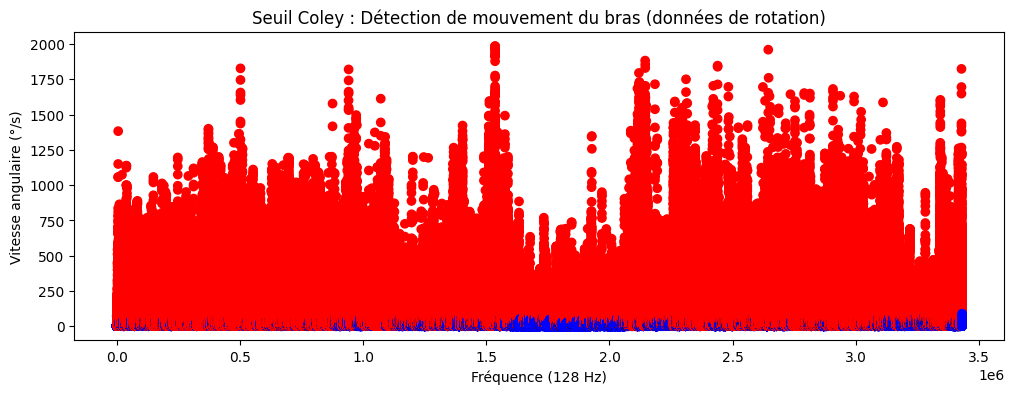

In [91]:
# ------------------------- Norme des mouvements ---------------------------
acc_data = []
acc_data_1s = []
for i in range(len(X_gyro_dom)):#for i in range(0,len(X_gyro_dom), 128):
    coordonnes = np.array([X_gyro_dom[i], Y_gyro_dom[i], Z_gyro_dom[i]])
    """for j in range(1, 128):
        coordonnes = np.array([X_gyro_dom[i], Y_gyro_dom[i], Z_gyro_dom[i]])
        norme_1s = np.linalg.norm(coordonnes)
        acc_data_1s.append(norme_1s)"""
    norme = np.linalg.norm(coordonnes)
    acc_data.append(norme)


#-------------------------- Paramètres --------------------------
sampling_rate = 128 
merge_window = int(1 * sampling_rate)  # 1 seconde
gap_threshold = int(0.5 * sampling_rate)  # 0.5 seconde
min_duration = int(1.5 * sampling_rate)  # 1.5 seconde

#-------------------------- Extraire les 3 axes gyroscopiques --------------------------
gyro_x = X_gyro_dom
gyro_y = Y_gyro_dom
gyro_z = Z_gyro_dom

#-------------------------- Détection des pics > 10°/s sur chaque axe --------------------------
mask_x = np.abs(np.array(gyro_x)) > 10
mask_y = np.abs(np.array(gyro_y)) > 10
mask_z = np.abs(np.array(gyro_z)) > 10

detected_x = np.abs(np.array(gyro_x)[mask_x])
detected_y = np.abs(np.array(gyro_y)[mask_y])
detected_z = np.abs(np.array(gyro_z)[mask_z])

#-------------------------- Moyenne des pics par axe --------------------------
    
mean_x = detected_x.mean() if len(detected_x) > 0 else np.inf
mean_y = detected_y.mean() if len(detected_y) > 0 else np.inf
mean_z = detected_z.mean() if len(detected_z) > 0 else np.inf

#-------------------------- Seuil adaptatif = min des moyennes --------------------------
adaptive_threshold = min(mean_x, mean_y, mean_z)
print(f"Seuil adaptatif : {adaptive_threshold:.2f} °/s")

#-------------------------- Détection brute : un mouvement si un axe dépasse le seuil --------------------------
   
movement_raw = (
    (np.abs(gyro_x) > adaptive_threshold) |
    (np.abs(gyro_y) > adaptive_threshold) |
    (np.abs(gyro_z) > adaptive_threshold)
).astype(int)


#-------------------------- Filtre max mobile (fusionner les mouvements séparés de < 0.5s) --------------------------
movement_merged = maximum_filter1d(movement_raw, size = merge_window)

#-------------------------- Filtre médian mobile (supprimer les mouvements < 1.5s) --------------------------
movement_prediction = medfilt(movement_merged, kernel_size = min_duration | 1)  # le paramètre kernel doit etre impair
# 8. Visualisation
color_map = {0: 'blue', 1: 'red'}
# Convertir les labels en couleurs
colors = [color_map[label] for label in movement_prediction]

plt.figure(figsize=(12, 4))
#plt.plot(np.linalg.norm(movement_prediction, axis=1), label="Norme Gyro") # calcul de la norme du mouvement final
plt.scatter(range(len(acc_data)), acc_data, c=colors) # plt.plot(movement_prediction * adaptive_threshold, label="Mouvement détecté", color='orange')
plt.title("Seuil Coley : Détection de mouvement du bras (données de rotation)")
plt.xlabel("Fréquence (128 Hz)")
plt.ylabel("Vitesse angulaire (°/s)")
plt.show()


Récupération des données d'accélération et de leur annotations (vérité)

In [92]:
# LES X ET Y SONT SYNCHRONISE JUSTE LES Y NE CORRESPONDENT PAS DIRRECTEMENT AUX SECONDES DU EXCEL : CE SONT (LES SECONDES DU EXCEL)-(LE TEMPS DE DEPART)
# POUR LE FICHIER DATA 10 LES ANNOTATIONS SONT DECALEES DE 7 SEC

folder_path = "C:/Users/roman/Documents/BEaCHILD/X_et_Y" 
folder = os.listdir(folder_path)

#////////////////////////////// Attention : le fichier LW est défini comme le dominant ////////////////////////////////

# Initialisation des listes contenant les données des capteurs
X_non_dom = []
X_dom = []
idx_X_non_dom = 0
idx_X_dom = 0
idx_Y_dom = 0
idx_Y_non_dom = 0

# Initialisation des listes contenant les annotations vidéos
Y_non_dom = [] 
Y_dom = []


#Parcourir les fichiers CSV
for file in folder[4:7]: # //////////////////////// Ajuster les indices pour choisir le fichier à analyser
    print(f"On est dans le fichier : {file}")

    # Extension du fichier
    extension = os.path.splitext(file)[1] 

    # Pour les cas ou il y a des annotations avant le start
    allow_start_dom = None
    allow_start_non_dom = None

    """********************************************************************** 1. Lecture des fichiers csv ******************************************************************************"""
    if extension == ".csv":

        # Visualisation des données des capteurs
        data_file = pd.read_csv(folder_path + "/" + file, header = 5, names = ["Timestamp","Gyro X","Gyro Y","Gyro Z","Accelerometer X","Accelerometer Y","Accelerometer Z","Event","Quat W","Quat X","Quat Y","Quat Z","None"])    

        # Conversion en AC 
        dom_AC = convert_AC(folder_path + "/" + file)

        # Enregistrement des données des capteurs dans les listes qui seront donnnées au classificateur
        if file[-11:-4] == "non_dom":
            list_dom_AC = dom_AC["AC"].tolist()
            for ac in list_dom_AC :
                X_non_dom.append(ac)

        elif file[-7:-4] == "dom":
            list_dom_AC = dom_AC["AC"].tolist()
            for ac in list_dom_AC:
                X_dom.append(ac)

    """********************************************************** 2. Enregistrer les annotations ***************************************************************************"""

    if extension == ".xlsx":

        my_wb = openpyxl.load_workbook(folder_path + "/" + file) 
        my_sheet = my_wb.active

        # Initialisation des décalages : sert pour éviter le décalage du aux arrondis des annotations 
        decalage_dom = 0
        decalage_non_dom = 0

        for label in my_sheet["H"]: 

            """*********************************************** Récupération du début de Y ****************************************************"""
            # dom
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_LW" :
                previous_row_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_dom = True

            # non_dom 
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_RW" :
                previous_row_non_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_non_dom = True

            """****************************************************** Récupération du contenu de Y ****************************************"""

            if label.value[0:2] == "LW" and allow_start_dom:

                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_dom, 13).value:
                    difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_dom , 13).value)) 
                    for diff in range(0,difference):
                        Y_dom.append(None) 
                    
                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value))) 
                for nb_sec in range(nb_repetitions): 
                    if X_dom and (len(Y_dom) == len(X_dom)) :
                        break
                    if label.value[3:13] == "sédentaire" :
                        Y_dom.append("non mouvement")
                    elif label.value[-2:] == "GA" or label.value[-2:] == "FA":
                        Y_dom.append("mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_dom.append(None) 


                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_dom = label.row


            elif label.value[0:2] == "RW" and allow_start_non_dom:
                
                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_non_dom, 13).value:
                    difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_non_dom , 13).value)) 
                    for diff in range(0,difference):
                        Y_non_dom.append(None) #.append("décalage annotations")

                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value)))
                for nb_sec in range(nb_repetitions): 
                    if X_non_dom and (len(Y_non_dom) == len(X_non_dom)): 
                        break
                    if label.value[3:13] == "sédentaire" :
                        Y_non_dom.append("non mouvement")
                    elif label.value[-2:] == "GA" or label.value[-2:] == "FA":
                        Y_non_dom.append("mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_non_dom.append(None)

                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_non_dom = label.row
        
        # CROPER X A LA LONGUEUR DE Y 
        X_dom = X_dom[:len(Y_dom)]
        X_non_dom = X_non_dom[:len(Y_non_dom)]
        Y_dom = Y_dom[:len(X_dom)]
        Y_non_dom = Y_non_dom[:len(X_non_dom)]

        print(f"len X_dom {len(X_dom)}")
        print(f"Y_dom {Y_dom[608 : 615]}")




On est dans le fichier : Data_11_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_11_non_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_11_X.xlsx
len X_dom 3629
Y_dom ['mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement']


In [93]:
# Laisser X_dom et faire tous les fichiers puis modifier X_non_dom et modifier dans le 2 cadre pour faire coley sur les non_dom, et refaire les fichiers
X_studied = X_dom
Y_studied = Y_dom

Modification de la fréquence des annotations prédites à 128 Hz pour comparer à la vérité (1 Hz)

In [94]:
def downsample_to_1Hz(binary_array, sampling_rate = 128):
    n_seconds = len(binary_array) // sampling_rate
    # Troncature pour être multiple de 128
    binary_array = binary_array[:n_seconds * sampling_rate]  
    # Vote à la majorité : si au moins 64 échantillons sont actifs, on considère la seconde comme mouvement
    reshaped = binary_array.reshape(n_seconds, sampling_rate)
    return (reshaped.sum(axis=1) >= (sampling_rate // 2)).astype(int)

predicted_1Hz = downsample_to_1Hz(movement_prediction)

# Coupure des annotations prédictive à la longueur des données d'accélération (les données de mouvement ne sont pas toutes annotées)
predicted_1Hz = predicted_1Hz[:len(X_studied)]


Affichage comparaison annotations prédites et vérites (sans nettoyage des données = avec données None)

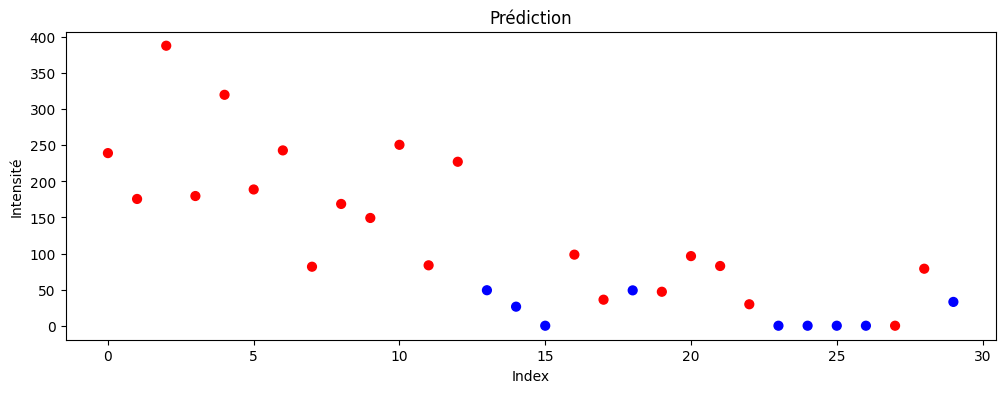

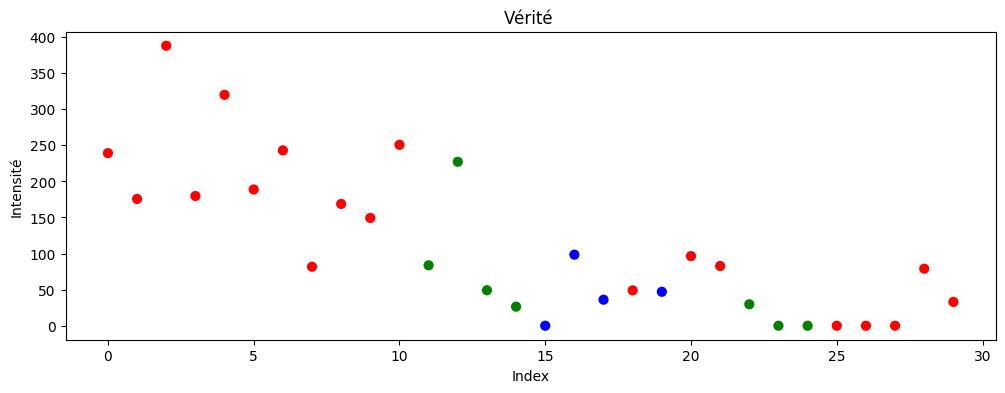

In [95]:
# Convertir les labels en couleurs
color_map = {0: 'blue', 1: 'red'}
colors = [color_map[label] for label in predicted_1Hz[730:760]]

plt.figure(figsize=(12, 4))
plt.scatter(range(len(X_studied[730:760])), X_studied[730:760], c=colors, s=40)
plt.title("Prédiction") 
plt.xlabel("Index")
plt.ylabel("Intensité")
plt.show()

true_color_map = {'non mouvement': 'blue', 'mouvement': 'red', None: 'green'}
# Convertir les labels en couleurs
true_colors = [true_color_map[label] for label in Y_studied[730:760]]

plt.figure(figsize=(12, 4))
plt.scatter(range(len(X_studied[730:760])), X_studied[730:760], c=true_colors, s=40)
plt.title("Vérité ") 
plt.xlabel("Index")
plt.ylabel("Intensité")
plt.show()

Affichage comparaison annotations prédites et vérité (données nettoyées)

In [96]:
# Convertir en array pour faciliter le filtrage
X_array = np.array(X_studied)
Y_array = np.array(Y_studied)

# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_None = Y_array != None
# Appliquer le masque aux données d'accelération
X_clean = X_array[mask_None]
Y_clean = Y_array[mask_None]

# Aplatir les données (mettre au bon format pour les modèles)
X_flat = np.vstack(X_clean)  
Y_flat = np.hstack(Y_clean) 

# Appliquer le masque aux annotations prédites (rotations)
predicted_1Hz_clean = predicted_1Hz[mask_None]
# Convertir les 1 et 0 en mouvement et non mouvement
predicted_1Hz_clean_balanced_str = np.where(predicted_1Hz_clean == 1, "mouvement", "non mouvement")


Préparation des données

In [97]:
"""#Equilibrer les données : autant de mouvement que de non mouvement, et dans le meme ordre que X_array et Y_array
# Compter les "non mouvement"
n_non_mvt = np.sum(Y_clean == 'non mouvement')
n_mvt = np.sum(Y_clean == 'mouvement')
# Sélectionner les indices dans l’ordre original
indices_mvt = np.where(Y_clean == 'mouvement')[0]
indices_non_mvt = np.where(Y_clean == 'non mouvement')[0]
# Si plus de mouvement
if n_non_mvt < n_mvt:
    # Garder les premiers `mouvement` rencontrés dans l'ordre
    indices_mvt_crop = indices_mvt[:n_non_mvt]
    # Fusionner les indices en gardant l’ordre du tableau initial
    indices_final = sorted(np.concatenate((indices_non_mvt, indices_mvt_crop)))
# Si plus de non mouvement
elif n_mvt < n_non_mvt :
    # Garder les premiers `non mouvement` rencontrés dans l'ordre
    indices_non_mvt_crop = indices_non_mvt[:n_mvt]
    # Fusionner les indices en gardant l’ordre du tableau initial
    indices_final = sorted(np.concatenate((indices_mvt, indices_non_mvt_crop)))

# Réorganise X et Y
X_balanced = X_clean[indices_final]
Y_balanced = Y_clean[indices_final]
predicted_1Hz_clean_balanced = predicted_1Hz_clean[indices_final]
# Aplatir les données (mettre au bon format pour les modèles)
X_flat = np.vstack(X_balanced)  
Y_flat = np.hstack(Y_balanced) 

print(len(X_flat))
print(len(Y_flat))
# Convertir les 1 et 0 en mouvement et non mouvement
predicted_1Hz_clean_balanced_str = np.where(predicted_1Hz_clean_balanced == 1, "mouvement", "non mouvement")"""

'#Equilibrer les données : autant de mouvement que de non mouvement, et dans le meme ordre que X_array et Y_array\n# Compter les "non mouvement"\nn_non_mvt = np.sum(Y_clean == \'non mouvement\')\nn_mvt = np.sum(Y_clean == \'mouvement\')\n# Sélectionner les indices dans l’ordre original\nindices_mvt = np.where(Y_clean == \'mouvement\')[0]\nindices_non_mvt = np.where(Y_clean == \'non mouvement\')[0]\n# Si plus de mouvement\nif n_non_mvt < n_mvt:\n    # Garder les premiers `mouvement` rencontrés dans l\'ordre\n    indices_mvt_crop = indices_mvt[:n_non_mvt]\n    # Fusionner les indices en gardant l’ordre du tableau initial\n    indices_final = sorted(np.concatenate((indices_non_mvt, indices_mvt_crop)))\n# Si plus de non mouvement\nelif n_mvt < n_non_mvt :\n    # Garder les premiers `non mouvement` rencontrés dans l\'ordre\n    indices_non_mvt_crop = indices_non_mvt[:n_mvt]\n    # Fusionner les indices en gardant l’ordre du tableau initial\n    indices_final = sorted(np.concatenate((indices

In [98]:
"""# Convertir les labels en couleurs
color_map = {'non mouvement': 'blue', 'mouvement': 'red'}
colors = [color_map[label] for label in predicted_1Hz_clean_balanced_str]

plt.figure(figsize=(12, 4))
plt.scatter(range(len(X_flat)), X_flat, c=colors, s=40)
plt.title("Prédiction") 
plt.xlabel("Index")
plt.ylabel("Intensité")
plt.show()

true_color_map = {'non mouvement': 'blue', 'mouvement': 'red'}
# Convertir les labels en couleurs
true_colors = [true_color_map[label] for label in Y_flat]

plt.figure(figsize=(12, 4))
plt.scatter(range(len(X_flat)), X_flat, c=true_colors, s=40) 
plt.title("Vérité ") 
plt.xlabel("Index")
plt.ylabel("Intensité")
plt.show()"""

'# Convertir les labels en couleurs\ncolor_map = {\'non mouvement\': \'blue\', \'mouvement\': \'red\'}\ncolors = [color_map[label] for label in predicted_1Hz_clean_balanced_str]\n\nplt.figure(figsize=(12, 4))\nplt.scatter(range(len(X_flat)), X_flat, c=colors, s=40)\nplt.title("Prédiction") \nplt.xlabel("Index")\nplt.ylabel("Intensité")\nplt.show()\n\ntrue_color_map = {\'non mouvement\': \'blue\', \'mouvement\': \'red\'}\n# Convertir les labels en couleurs\ntrue_colors = [true_color_map[label] for label in Y_flat]\n\nplt.figure(figsize=(12, 4))\nplt.scatter(range(len(X_flat)), X_flat, c=true_colors, s=40) \nplt.title("Vérité ") \nplt.xlabel("Index")\nplt.ylabel("Intensité")\nplt.show()'

Analyse des prédictions

len X_flat : 3247
F1 score non mouvement:  0.12014134275618374
F1 score mouvement :  0.9599098373852841
F1 score weighted:  0.9482715305610434
F1 score macro :  0.5400255900707339
Accuracy pour seuil adaptatif de Coley : 0.92


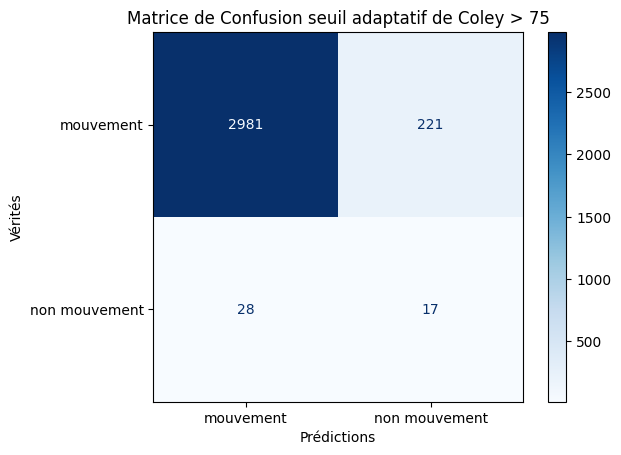

In [99]:

# Evaluate the model
# F1 score
print("len X_flat :", len(X_flat))
f1score_mouvement = f1_score(Y_flat, predicted_1Hz_clean_balanced_str, labels = ["non mouvement","mouvement"], pos_label = "mouvement", average = "binary")
f1score_non_mouvement = f1_score(Y_flat, predicted_1Hz_clean_balanced_str, labels = ["non mouvement","mouvement"], pos_label = "non mouvement", average = "binary")
f1score_weighted = f1_score(Y_flat, predicted_1Hz_clean_balanced_str, labels = ["non mouvement","mouvement"], average = "weighted")
f1score_macro = f1_score(Y_flat, predicted_1Hz_clean_balanced_str, labels = ["non mouvement","mouvement"], average = "macro")

print("F1 score non mouvement: ", f1score_non_mouvement)
print("F1 score mouvement : ", f1score_mouvement)
print("F1 score weighted: ", f1score_weighted)
print("F1 score macro : ", f1score_macro)

# Accuracy
accuracy = accuracy_score(Y_flat, predicted_1Hz_clean_balanced_str)
print(f"Accuracy pour seuil adaptatif de Coley : {accuracy:.2f}")
cm_adaptatif = confusion_matrix(Y_flat, predicted_1Hz_clean_balanced_str)

# Afficher la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm_adaptatif, display_labels= ["mouvement", "non mouvement"])
disp.plot(cmap="Blues")
disp.ax_.set_title("Matrice de Confusion seuil adaptatif de Coley > 75")
disp.ax_.set_xlabel("Prédictions")
disp.ax_.set_ylabel("Vérités")
#disp.figure_.show()
plt.show()